# Project Description

The Sweet Lift Taxi company has collected historical data on taxi orders at airports. To attract more drivers during peak hours, we need to predict the number of taxi orders for the next hour. Build a model for this prediction.

The RMSE metric on the test set must not be higher than 48.
**The RMSE metric** means root mean squared error and is widely used in regression models to **measure how far predictions are from the actual values.**

## Project Instructions.

1. Download the data and resample it by one hour.
2. Analyze the data.
3. Train different models with different hyperparameters. The test sample must be 10% of the initial dataset.
4. Test the data using the test sample and provide a conclusion.

## Data Description

The data is stored in the `taxi.csv` file. 	
The number of orders is in the `num_orders` column.

## Preparation

In [1]:
# import libraries

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

In [2]:
# Load the data
data = pd.read_csv('datasets/taxi.csv', parse_dates=[0])
print(data.info)
print(data.head)

<bound method DataFrame.info of                  datetime  num_orders
0     2018-03-01 00:00:00           9
1     2018-03-01 00:10:00          14
2     2018-03-01 00:20:00          28
3     2018-03-01 00:30:00          20
4     2018-03-01 00:40:00          32
...                   ...         ...
26491 2018-08-31 23:10:00          32
26492 2018-08-31 23:20:00          24
26493 2018-08-31 23:30:00          27
26494 2018-08-31 23:40:00          39
26495 2018-08-31 23:50:00          53

[26496 rows x 2 columns]>
<bound method NDFrame.head of                  datetime  num_orders
0     2018-03-01 00:00:00           9
1     2018-03-01 00:10:00          14
2     2018-03-01 00:20:00          28
3     2018-03-01 00:30:00          20
4     2018-03-01 00:40:00          32
...                   ...         ...
26491 2018-08-31 23:10:00          32
26492 2018-08-31 23:20:00          24
26493 2018-08-31 23:30:00          27
26494 2018-08-31 23:40:00          39
26495 2018-08-31 23:50:00          53

In [3]:
# Set the date as the index
data.set_index('datetime', inplace=True)

# Sort by index
data.sort_index(inplace=True)

# Resample at 1-hour intervals
data = data.resample('1h').sum()

# Review
print(data.info())
print(data.head())


<class 'pandas.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: h
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB
None
                     num_orders
datetime                       
2018-03-01 00:00:00         124
2018-03-01 01:00:00          85
2018-03-01 02:00:00          71
2018-03-01 03:00:00          66
2018-03-01 04:00:00          43


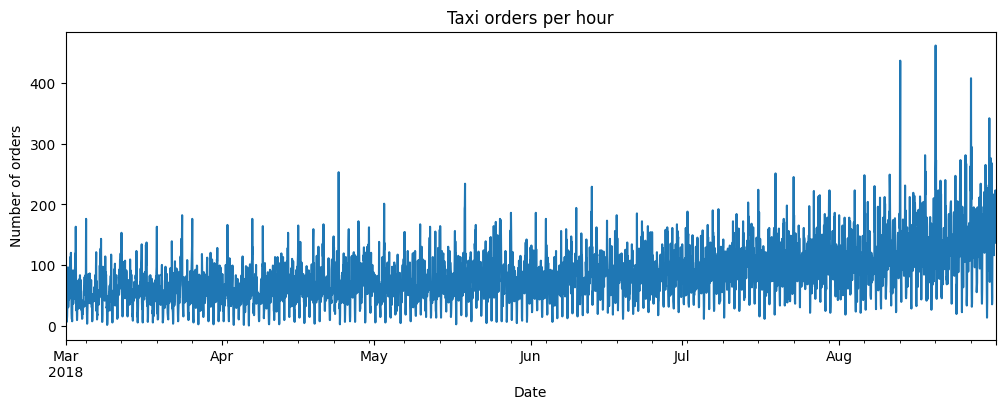

In [4]:
# Initial chart to view general behavior
data['num_orders'].plot(figsize=(12,4))
plt.title("Taxi orders per hour")
plt.xlabel("Date")
plt.ylabel("Number of orders")
plt.show()

## Analysis

- After loading the taxi.csv file, the date column was converted to a DatetimeIndex, the dataset was sorted chronologically, and resampling was performed at one-hour intervals.

- After this process, the final dataset contained 4416 records, each representing the total number of taxi orders received in each hour during the period from March to August 2018.

- Using the .info() method, it was verified that the num_orders column contains no missing values, which allows the analysis to continue without additional imputation.

The initial chart shows several important patterns:

- There is strong variability in the number of orders per hour, ranging from low values during many hours of the day to considerable peaks at certain times.
- Progressive increases are observed toward the end of the period, suggesting a possible overall upward trend.
- Abrupt fluctuations are also visible, consistent with daily or weekly seasonality typical of transportation (peak hours, weekends, etc.).
- The highest peaks exceed 100 orders per hour, indicating moments of extreme demand.

Overall, these results suggest that the time series contains a mixture of seasonality, trend, and random variation, making it appropriate to use time series models with additional features such as lags or rolling windows to improve the next-hour prediction.

## Training

A make_features() function is created to generate features
- Year
- Month
- Day
- Day of the week
- Lags
- Rolling mean

In [5]:
def make_features(data, max_lag=24, rolling_mean_size=24):
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    
    # Lags
    for lag in range(1, max_lag + 1):
        data[f'lag_{lag}'] = data['num_orders'].shift(lag)
    
    # Rolling mean without data leakage
    data['rolling_mean'] = data['num_orders'].shift(1).rolling(rolling_mean_size).mean()
    
    return data

In [6]:
# Apply the function to the dataset
data_features = make_features(data.copy(), max_lag=24, rolling_mean_size=24)

In [7]:
# Split into Train and Test

train, test = train_test_split(data_features, shuffle=False, test_size=0.1)

# Remove NaN values from train, generated by the lags and rolling mean
train = train.dropna()

In [8]:
# Select features and target
target = 'num_orders'
features = train.columns.drop(target)

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

### Linear Regression

In [9]:
# train a baseline model, linear regression
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

pred_train_lr = model_lr.predict(X_train)
pred_test_lr = model_lr.predict(X_test)

In [10]:
# Calculate RMSE
rmse_train = np.sqrt(mean_squared_error(y_train, pred_train_lr))
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test_lr))

print("RMSE Train:", rmse_train)
print("RMSE Test:", rmse_test)

RMSE Train: 25.818602103995374
RMSE Test: 45.52933708020935


### Random Forest

In [11]:
rf_model = RandomForestRegressor(
    n_estimators=300,   # number of trees
    max_depth=15,       # maximum depth
    random_state=42,
    n_jobs=-1           # uses all available cores
)

rf_model.fit(X_train, y_train)

# Predictions
pred_train_rf = rf_model.predict(X_train)
pred_test_rf = rf_model.predict(X_test)

# RMSE
rmse_train_rf = np.sqrt(mean_squared_error(y_train, pred_train_rf))
rmse_test_rf = np.sqrt(mean_squared_error(y_test, pred_test_rf))

print("Random Forest - RMSE Train:", rmse_train_rf)
print("Random Forest - RMSE Test:", rmse_test_rf)

Random Forest - RMSE Train: 9.755721663974008
Random Forest - RMSE Test: 43.39490791478649


In [12]:
param_grid = [
    (100, 8),
    (200, 12),
    (300, 15),
]

for n_est, depth in param_grid:
    model = RandomForestRegressor(
        n_estimators=n_est,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    pred_test = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    print(f"n_estimators={n_est}, max_depth={depth} -> RMSE Test = {rmse:.2f}")

n_estimators=100, max_depth=8 -> RMSE Test = 44.51


n_estimators=200, max_depth=12 -> RMSE Test = 43.61


n_estimators=300, max_depth=15 -> RMSE Test = 43.39


### Gradient Boosting

In [13]:
gbr_model = GradientBoostingRegressor(
    n_estimators=300,    # number of weak trees
    learning_rate=0.05,  # step size
    max_depth=3,         # depth of each tree
    random_state=42
)

gbr_model.fit(X_train, y_train)

# Predictions
pred_train_gbr = gbr_model.predict(X_train)
pred_test_gbr = gbr_model.predict(X_test)

# RMSE
rmse_train_gbr = np.sqrt(mean_squared_error(y_train, pred_train_gbr))
rmse_test_gbr = np.sqrt(mean_squared_error(y_test, pred_test_gbr))

print("Gradient Boosting - RMSE Train:", rmse_train_gbr)
print("Gradient Boosting - RMSE Test:", rmse_test_gbr)

Gradient Boosting - RMSE Train: 19.31811224278561
Gradient Boosting - RMSE Test: 44.547910348765946


In [14]:
param_grid_gbr = [
    (100, 0.1),
    (200, 0.05),
    (300, 0.05),
]

for n_est, lr in param_grid_gbr:
    model = GradientBoostingRegressor(
        n_estimators=n_est,
        learning_rate=lr,
        max_depth=3,
        random_state=42
    )
    model.fit(X_train, y_train)
    pred_test = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    print(f"n_estimators={n_est}, learning_rate={lr} -> RMSE Test = {rmse:.2f}")

n_estimators=100, learning_rate=0.1 -> RMSE Test = 45.25


n_estimators=200, learning_rate=0.05 -> RMSE Test = 44.55


n_estimators=300, learning_rate=0.05 -> RMSE Test = 44.55


### CatBoost

In [15]:
cat_model = CatBoostRegressor(
    iterations=500,       # number of trees
    learning_rate=0.05,   # learning rate
    depth=6,              # tree depth
    loss_function='RMSE',
    random_state=42,
    verbose=False         # prevents printing every iteration
)

cat_model.fit(X_train, y_train)

# Predictions
pred_train_cat = cat_model.predict(X_train)
pred_test_cat = cat_model.predict(X_test)

# RMSE
rmse_train_cat = np.sqrt(mean_squared_error(y_train, pred_train_cat))
rmse_test_cat = np.sqrt(mean_squared_error(y_test, pred_test_cat))

print("CatBoost - RMSE Train:", rmse_train_cat)
print("CatBoost - RMSE Test:", rmse_test_cat)

CatBoost - RMSE Train: 15.541460145392195
CatBoost - RMSE Test: 40.898393583984635


In [16]:
param_grid_cat = [
    # (iterations, learning_rate, depth)
    (300, 0.1, 6),
    (500, 0.05, 6),
    (700, 0.03, 8),
]

for iters, lr, depth in param_grid_cat:
    model = CatBoostRegressor(
        iterations=iters,
        learning_rate=lr,
        depth=depth,
        loss_function='RMSE',
        random_state=42,
        verbose=False
    )
    
    model.fit(X_train, y_train)
    pred_test = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    print(
        f"iterations={iters}, learning_rate={lr}, depth={depth} "
        f"-> RMSE Test = {rmse:.2f}"
    )

iterations=300, learning_rate=0.1, depth=6 -> RMSE Test = 41.56


iterations=500, learning_rate=0.05, depth=6 -> RMSE Test = 40.90


iterations=700, learning_rate=0.03, depth=8 -> RMSE Test = 42.44


### LightGBM

In [17]:
lgb_model = LGBMRegressor(
    n_estimators=700,     # number of trees
    learning_rate=0.03,   # learning rate
    max_depth=-1,         # -1 = no depth limit
    num_leaves=64,        # controls complexity
    random_state=42
)

lgb_model.fit(X_train, y_train)

# Predictions
pred_train_lgb = lgb_model.predict(X_train)
pred_test_lgb = lgb_model.predict(X_test)

# RMSE
rmse_train_lgb = np.sqrt(mean_squared_error(y_train, pred_train_lgb))
rmse_test_lgb = np.sqrt(mean_squared_error(y_test, pred_test_lgb))

print("LightGBM - RMSE Train:", rmse_train_lgb)
print("LightGBM - RMSE Test:", rmse_test_lgb)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000997 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4851
[LightGBM] [Info] Number of data points in the train set: 3950, number of used features: 28
[LightGBM] [Info] Start training from score 78.421013


LightGBM - RMSE Train: 3.5571404892445533
LightGBM - RMSE Test: 42.74953077542683


In [18]:
param_grid_lgb = [
    (300, 0.1),
    (500, 0.05),
    (700, 0.03),
]

for n_est, lr in param_grid_lgb:
    model = LGBMRegressor(
        n_estimators=n_est,
        learning_rate=lr,
        num_leaves=64,
        random_state=42
    )
    model.fit(X_train, y_train)
    pred_test = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    print(f"n_estimators={n_est}, learning_rate={lr} -> RMSE Test = {rmse:.2f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001011 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4851
[LightGBM] [Info] Number of data points in the train set: 3950, number of used features: 28
[LightGBM] [Info] Start training from score 78.421013


n_estimators=300, learning_rate=0.1 -> RMSE Test = 43.00
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001195 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4851
[LightGBM] [Info] Number of data points in the train set: 3950, number of used features: 28
[LightGBM] [Info] Start training from score 78.421013


n_estimators=500, learning_rate=0.05 -> RMSE Test = 42.89
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000935 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4851
[LightGBM] [Info] Number of data points in the train set: 3950, number of used features: 28
[LightGBM] [Info] Start training from score 78.421013


n_estimators=700, learning_rate=0.03 -> RMSE Test = 42.75


## Test

In [19]:
# Train the best model found (CatBoost)
final_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_state=42,
    verbose=False
)

final_model.fit(X_train, y_train)

# Final predictions
final_pred_test = final_model.predict(X_test)

# Final RMSE calculation
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred_test))

print("Final RMSE of the selected model:", final_rmse)

Final RMSE of the selected model: 40.898393583984635


In [20]:
predictions_sample = pd.DataFrame({
    'real_orders': y_test,
    'predicted_orders': final_pred_test
}, index=y_test.index)

predictions_sample['predicted_orders'] = predictions_sample['predicted_orders'].round().astype(int)
predictions_sample['error'] = predictions_sample['real_orders'] - predictions_sample['predicted_orders']

predictions_sample.head(10)

,real_orders,predicted_orders,error
datetime,,,
2018-08-13 14:00:00,102,93,9
2018-08-13 15:00:00,175,111,64
2018-08-13 16:00:00,144,144,0
2018-08-13 17:00:00,152,146,6
2018-08-13 18:00:00,104,117,-13
2018-08-13 19:00:00,91,102,-11
2018-08-13 20:00:00,82,101,-19
2018-08-13 21:00:00,160,112,48
2018-08-13 22:00:00,104,130,-26


In [21]:
predictions_sample.iloc[0]

real_orders         102
predicted_orders     93
error                 9
Name: 2018-08-13 14:00:00, dtype: int64

In [22]:
predictions_sample.sample(10, random_state=42)

,real_orders,predicted_orders,error
datetime,,,
2018-08-25 13:00:00,63,92,-29
2018-08-22 09:00:00,136,132,4
2018-08-16 14:00:00,64,88,-24
2018-08-26 23:00:00,238,165,73
2018-08-16 15:00:00,110,97,13
2018-08-31 00:00:00,276,217,59
2018-08-28 21:00:00,189,123,66
2018-08-28 08:00:00,159,119,40
2018-08-25 07:00:00,22,60,-38


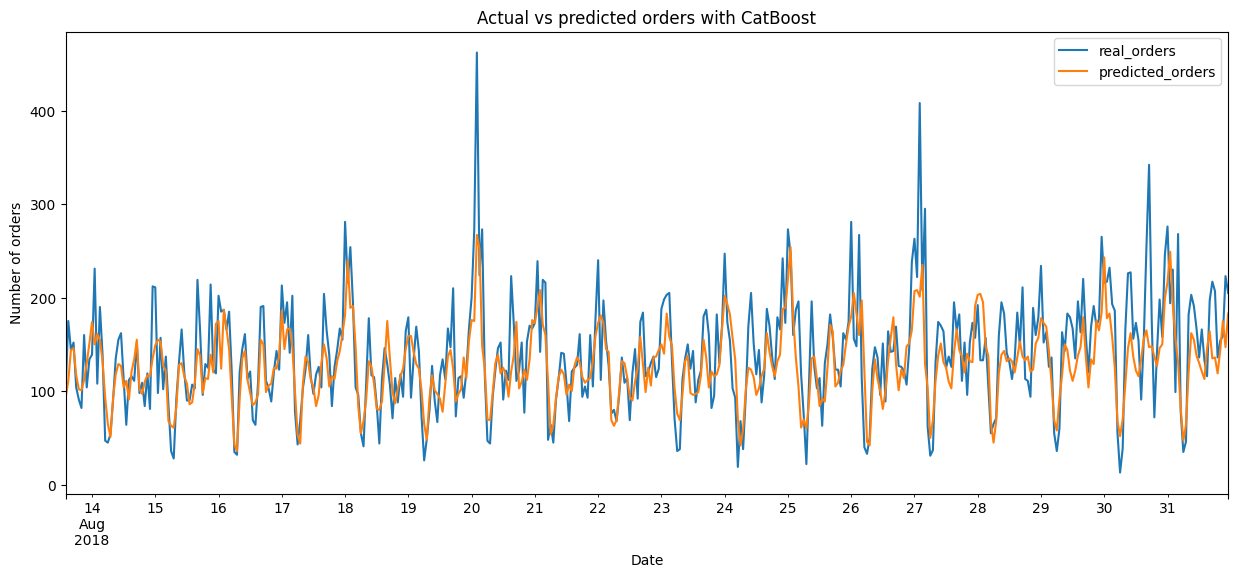

In [23]:
predictions_sample[['real_orders', 'predicted_orders']].plot(figsize=(15, 6))
plt.title('Actual vs predicted orders with CatBoost')
plt.xlabel('Date')
plt.ylabel('Number of orders')
plt.show()

In [24]:
next_hour_prediction = final_model.predict(X_test.tail(1))[0]

print(f"Prediction for the next hour: {round(next_hour_prediction)} taxi orders")

Prediction for the next hour: 183 taxi orders


#### For the test stage, the model with the best performance during the training phase was selected:

- After comparing several algorithms such as Linear Regression, Random Forest, Gradient Boosting, CatBoost 
and LightGBM, the model that achieved the lowest error on the test set was CatBoost, with an RMSE 
of approximately 40.89.

- In this section, the model was trained again using only training data, and I evaluated 
its performance on the reserved test set (10% of the initial total).
The final result was: final RMSE approximately 40.89

This value is below the threshold established in the project (RMSE <= 48), which indicates 
that the model is accurate enough to predict the number of taxi orders for the 
next hour. Therefore, CatBoost is considered the best candidate.

In addition to evaluating the model with RMSE, some individual predictions were compared against the actual values from the test set. This makes it possible to observe how the model behaves at specific hours and verify whether its estimates are reasonable for the expected taxi demand.

Although the model does not predict every hour exactly, its estimates closely follow the general demand trend. Therefore, it can be useful for anticipating periods of high demand and planning driver availability.

In [ ]:
def classify_demand(df, demand_col='num_orders'):
    low_threshold = df[demand_col].quantile(0.33)
    high_threshold = df[demand_col].quantile(0.75)
    peak_threshold = df[demand_col].quantile(0.95)

    def label_demand(value):
        if value >= peak_threshold:
            return 'peak demand'
        elif value >= high_threshold:
            return 'high demand'
        elif value <= low_threshold:
            return 'low demand'
        else:
            return 'medium demand'

    df = df.copy()
    df['demand_level'] = df[demand_col].apply(label_demand)

    return df

In [ ]:
# Create the demand level column
data_with_demand = classify_demand(data)

In [ ]:
# Check that the new column was created
data_with_demand.head()

In [ ]:
# Number of hourly observations by demand level
data_with_demand['demand_level'].value_counts()

In [ ]:
data_with_demand['demand_level'].value_counts().plot(
    kind='bar',
    title='Demand Level Distribution',
    xlabel='Demand level',
    ylabel='Number of hours'
)

In [ ]:
# Real order ranges by demand category
demand_summary = data_with_demand.groupby('demand_level')['num_orders'].describe()
demand_summary

In [ ]:
# Distribution of demand levels by hour of day
hourly_demand_levels = (
    data_with_demand
    .groupby([data_with_demand.index.hour, 'demand_level'])
    .size()
    .unstack(fill_value=0)
)

hourly_demand_levels

In [ ]:
# Hours with the highest presence of peak demand
peak_hours = hourly_demand_levels.sort_values('peak demand', ascending=False)
peak_hours.head(10)

#### Demand segmentation

The percentile-based classification separates hourly taxi orders into four demand levels: low, medium, high, and peak demand. Most observations fall into medium or low demand, while peak demand represents a smaller group of critical hours.

This segmentation complements the predictive model because it translates the estimated number of orders into an operational signal that is easier to interpret. In practice, hours classified as `high demand` or `peak demand` should receive more attention when planning driver availability.